In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

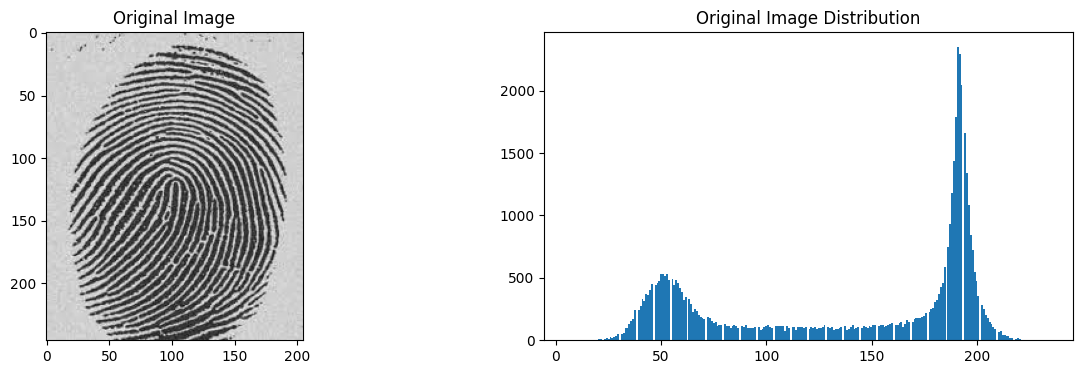

In [4]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('fingerprint.jpg', cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Error: Image not found. Check the file path.")
else:
    fig = plt.figure(figsize=(15, 4))

    ax1 = fig.add_subplot(121)
    ax2 = fig.add_subplot(122)

    ax1.imshow(image, cmap='gray')
    ax1.set_title('Original Image')

    ax2.hist(image.ravel(), bins=256)
    ax2.set_title('Original Image Distribution')

    plt.show()

In [7]:
import numpy as np

# Computing T Values until difference in T is smaller than T0
T = (np.max(image) + np.min(image)) / 2.0  # Initial estimate
T0 = 0  # Stop when threshold no longer changes

while True:
    print(f"Thresholding Value: {T}")

    # Flatten image
    flat_image = image.ravel()

    # Split into two groups
    u1_pixels = flat_image[flat_image > T]
    u2_pixels = flat_image[flat_image <= T]

    # Stop if one group becomes empty
    if len(u1_pixels) == 0 or len(u2_pixels) == 0:
        break

    # Calculate means
    m1 = np.mean(u1_pixels)
    m2 = np.mean(u2_pixels)

    # Compute new threshold
    T_new = (m1 + m2) / 2.0

    # Check convergence
    if abs(T_new - T) <= T0:
        T = T_new
        break

    T = T_new

# Apply global threshold
global_thres = image > T

Thresholding Value: 120.0
Thresholding Value: 123.80825488637441
Thresholding Value: 124.58247077719997
Thresholding Value: 124.81656905710813


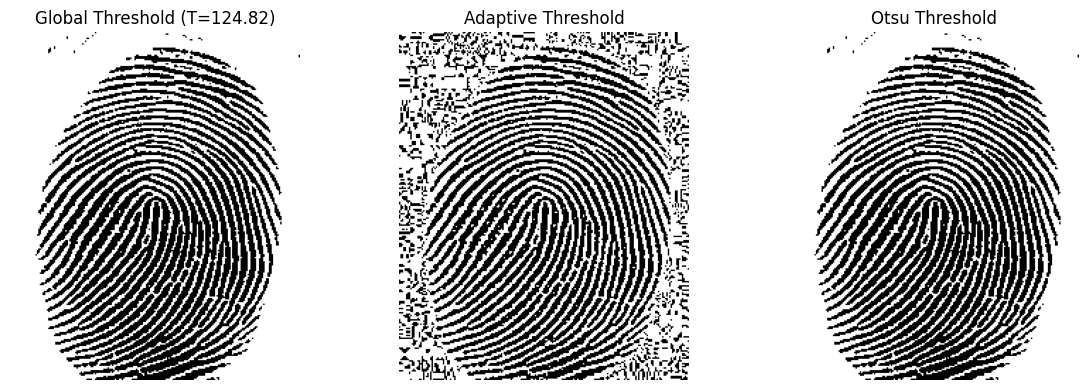

In [9]:
adaptive_thres = cv2.adaptiveThreshold(
    image,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

_, otsu_thres = cv2.threshold(
    image,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

fig = plt.figure(figsize=(12, 4))

ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

ax1.imshow(global_thres, cmap='gray')
ax1.set_title(f'Global Threshold (T={T:.2f})')
ax1.axis('off')

ax2.imshow(adaptive_thres, cmap='gray')
ax2.set_title('Adaptive Threshold')
ax2.axis('off')

ax3.imshow(otsu_thres, cmap='gray')
ax3.set_title('Otsu Threshold')
ax3.axis('off')

plt.tight_layout()
plt.show()

In [11]:
# Adaptive Threshold
adaptive_thres = cv2.adaptiveThreshold(
    image,
    255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

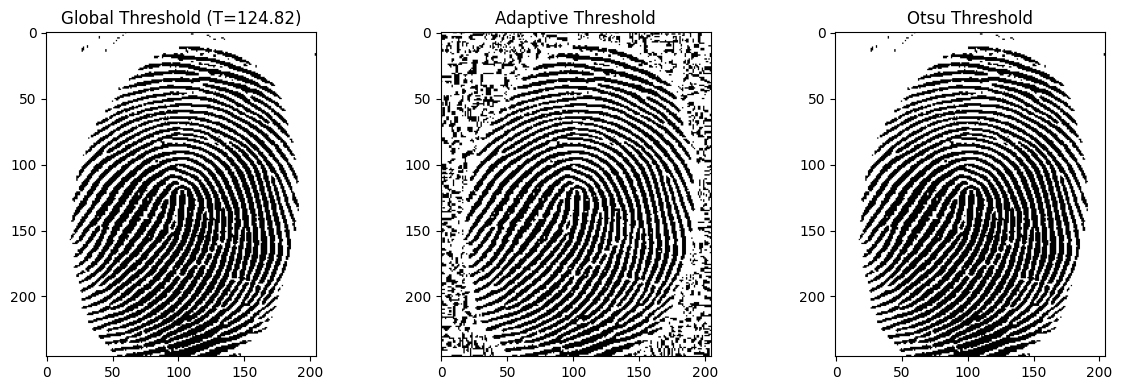

In [12]:
fig = plt.figure(figsize=(12,4))

ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

ax1.imshow(global_thres, cmap='gray')
ax1.set_title(f'Global Threshold (T={T:.2f})')

ax2.imshow(adaptive_thres, cmap='gray')
ax2.set_title('Adaptive Threshold')

ax3.imshow(otsu_thres, cmap='gray')
ax3.set_title('Otsu Threshold')

plt.tight_layout()
plt.show()

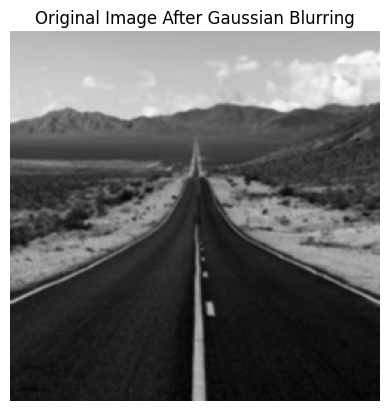

In [16]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('road.bmp', cv2.IMREAD_GRAYSCALE)

image = cv2.GaussianBlur(image, (3, 3), 0)

plt.imshow(image, cmap='gray')
plt.title('Original Image After Gaussian Blurring')
plt.axis('off')
plt.show()

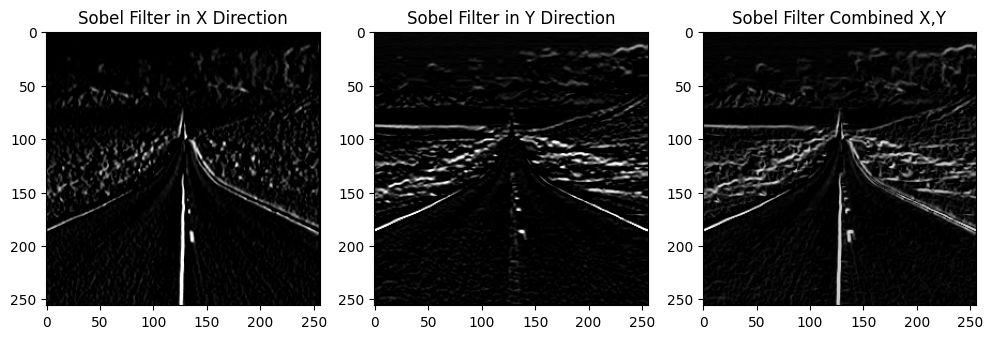

In [17]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

sobelX = cv2.Sobel(image, cv2.CV_8U, 1, 0, ksize=3).astype(np.uint64)
sobelY = cv2.Sobel(image, cv2.CV_8U, 0, 1, ksize=3).astype(np.uint64)
sobel = np.sqrt(np.power(sobelX, 2) + np.power(sobelY, 2)).astype(np.uint64)

fig = plt.figure(figsize=(12, 4))

ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

ax1.imshow(sobelX, cmap='gray')
ax1.set_title('Sobel Filter in X Direction')

ax2.imshow(sobelY, cmap='gray')
ax2.set_title('Sobel Filter in Y Direction')

ax3.imshow(sobel, cmap='gray')
ax3.set_title('Sobel Filter Combined X,Y')

plt.show()

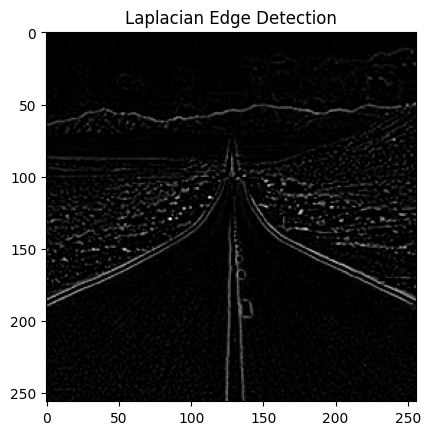

In [18]:
laplacian = cv2.Laplacian(image, cv2.CV_8U)
plt.imshow(laplacian, cmap='gray')
plt.title('Laplacian Edge Detection')
plt.show()

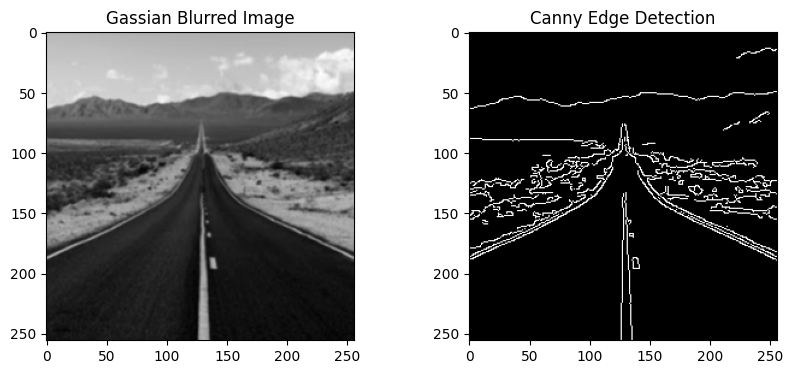

In [19]:
THRESHOLD1 = 100
THRESHOLD2 = 200
canny = cv2.Canny(image, THRESHOLD1, THRESHOLD2)
fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.imshow(image, cmap='gray')
ax1.title.set_text('Gassian Blurred Image')
ax2.imshow(canny, cmap='gray')
ax2.title.set_text('Canny Edge Detection')

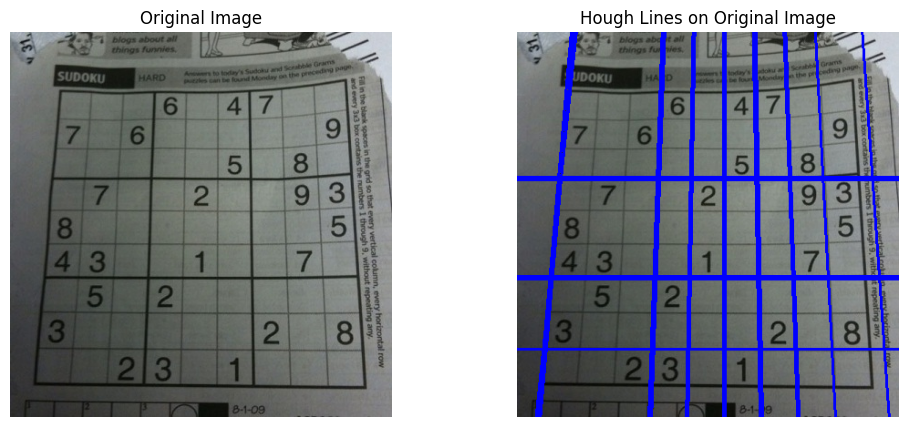

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Load the image
image_path = "sudoku-original.jpg"   # Change this path if needed

if not os.path.exists(image_path):
    print("Error: Image file not found!")
else:
    image = cv2.imread(image_path)

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Detect edges
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)

    # Detect Hough lines
    lines = cv2.HoughLines(edges, 1, np.pi/180, 200)

    # Make a copy of the image for drawing
    output = image.copy()

    # Draw detected lines
    if lines is not None:
        for line in lines:
            rho, theta = line[0]
            a = np.cos(theta)
            b = np.sin(theta)

            x0 = a * rho
            y0 = b * rho

            x1 = int(x0 + 1000 * (-b))
            y1 = int(y0 + 1000 * (a))
            x2 = int(x0 - 1000 * (-b))
            y2 = int(y0 - 1000 * (a))

            cv2.line(output, (x1, y1), (x2, y2), (255, 0, 0), 2)
    else:
        print("No lines detected.")

    # Display images
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.title("Hough Lines on Original Image")
    plt.axis("off")

    plt.show()

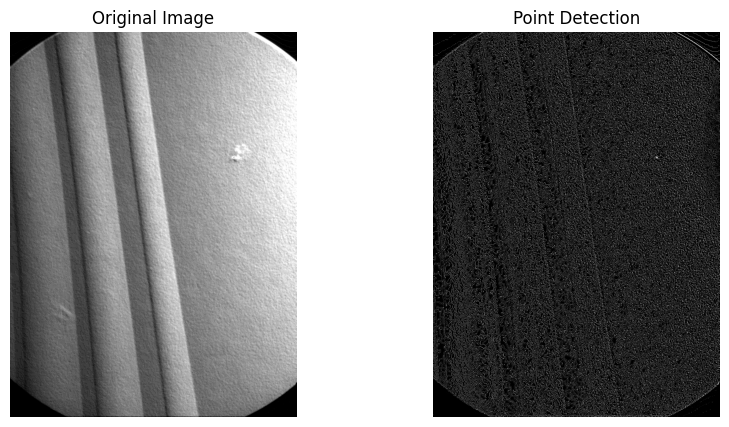

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('turbine.jpg', cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Error: turbine.jpg not found.")
else:
    point_detection_mask = np.array([
        [-1, -1, -1],
        [-1,  8, -1],
        [-1, -1, -1]
    ], dtype=np.float32)

    filtered = cv2.filter2D(image, -1, point_detection_mask)

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(image, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(filtered, cmap='gray')
    plt.title("Point Detection")
    plt.axis('off')

    plt.show()

NameError: name 'thresh' is not defined

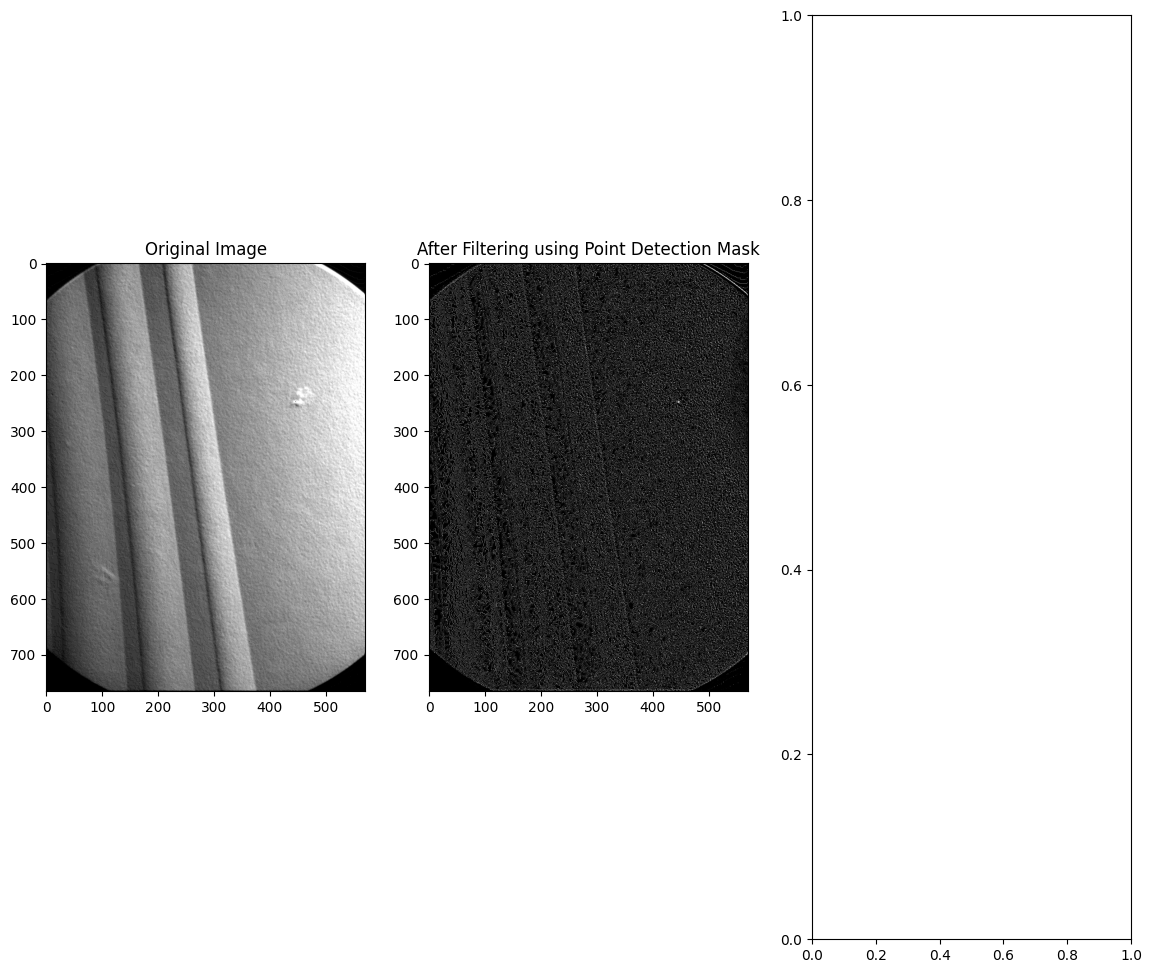

In [26]:
# Displaying Results
fig = plt.figure(figsize=(14, 12))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)
ax1.imshow(image, cmap='gray')
ax1.title.set_text('Original Image')
ax2.imshow(filtered, cmap='gray')
ax2.title.set_text('After Filtering using Point Detection Mask')
ax3.imshow(thresh, cmap='gray')
ax3.title.set_text('After Thresholding Filtered Image')